Coefficients: [ 0.11048404 -0.19018685  0.57970281  0.57970281 -0.19018685  0.11048404]


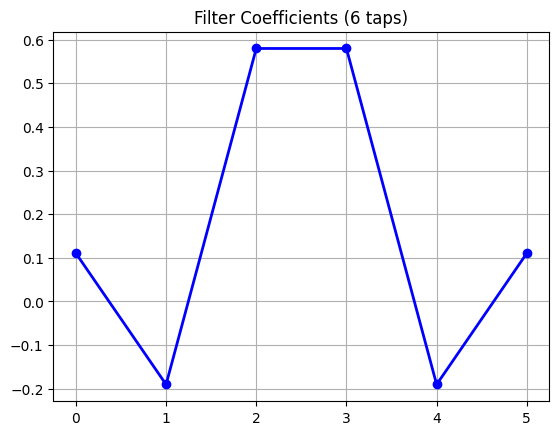

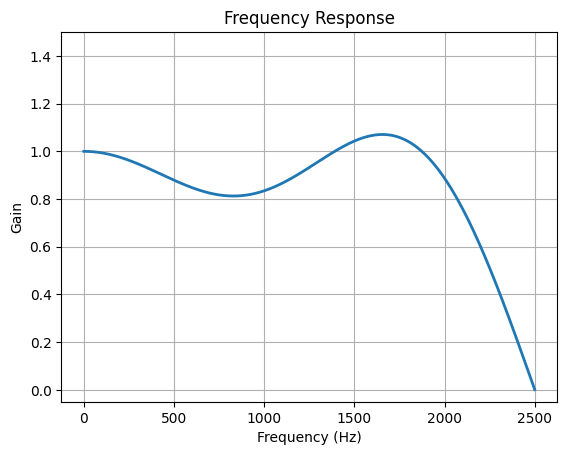

In [15]:
# Explore FIR Design
# https://scipy-cookbook.readthedocs.io/items/FIRFilter.html

from numpy import cos, sin, pi, absolute, arange
from scipy.signal import kaiserord, lfilter, firwin, freqz
from pylab import figure, clf, plot, xlabel, ylabel, xlim, ylim, title, grid, axes, show

# Define the filter specifications
sample_freq = 5000  # Hardware sample rate
nyq_rate = sample_freq / 2.0  # Nyquist rate
width = 1000.0 / nyq_rate  # Transition band width in Hz
ripple_db = 20   # Stopband attenuation in dB
cutoff_hz = 2400  # Cutoff frequency in Hz

# Design the FIR filter
N, beta = kaiserord(ripple_db, width)
taps = firwin(N, cutoff_hz / nyq_rate, window=('kaiser', beta))
print(f"Coefficients: {taps}")

# Compute the frequency response
w, h = freqz(taps)

#------------------------------------------------
# Plot the FIR filter coefficients.
#------------------------------------------------
figure(1)
plot(taps, 'bo-', linewidth=2)
title('Filter Coefficients (%d taps)' % N)
grid(True)

#------------------------------------------------
# Plot the magnitude response of the filter.
#------------------------------------------------
figure(2)
clf()
w, h = freqz(taps, worN=8000)
plot((w/pi)*nyq_rate, absolute(h), linewidth=2)
xlabel('Frequency (Hz)')
ylabel('Gain')
title('Frequency Response')
ylim(-0.05, 1.5)
grid(True)